# Titanic Dataset - Data Cleaning and Visualization

This is my second task. I'm learning to handle messy data and tell its story through visualizations. 

In [1]:
# Importing libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load training data
df = pd.read_csv('train.csv')

# Create a copy for cleaning
df_clean = df.copy()

print("Original shape:", df.shape)
df.head()

Original shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Missing values before cleaning:")
missing_before = df_clean.isnull().sum()
print(missing_before)

print("\nPercentage:")
print((missing_before / len(df_clean)) * 100)

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Percentage:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


## How I'm Handling Missing Values

**My decisions:**

1. **Cabin:** I'm dropping this column entirely. It has 687 missing values (77% of the data). Filling that many values wouldn't be reliable. Better to remove it.

2. **Age:** I'm filling with the median age. Age has 177 missing values (19.9%). Median is better than mean because age data might have outliers (like 80-year-old passengers).

3. **Embarked:** I'm filling with the mode (most common value). Only 2 missing values, so using the most frequent port (S for Southampton) makes sense.

In [4]:
# 1. Drop Cabin column
df_clean = df_clean.drop('Cabin', axis=1)

# 2. Fill Age with median
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)

# 3. Fill Embarked with mode
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)

# Verify cleaning
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print(f"\nAge filled with median: {age_median}")
print(f"Embarked filled with mode: {embarked_mode}")

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Age filled with median: 28.0
Embarked filled with mode: S


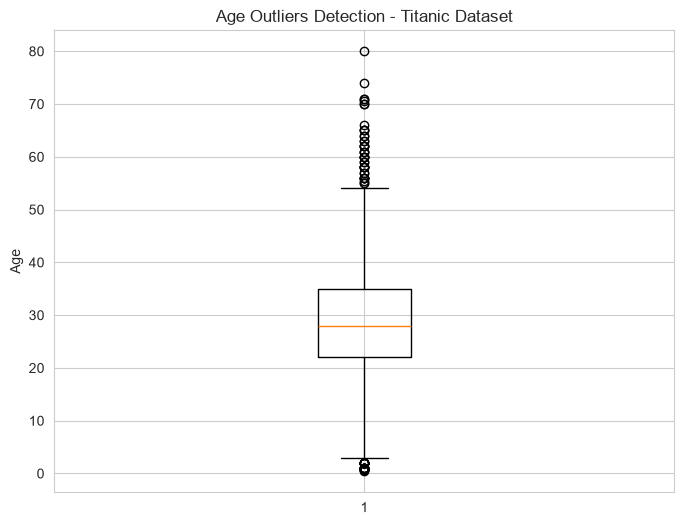

Q1: 22.00, Q3: 35.00, IQR: 13.00
Outlier bounds: 2.50 to 54.50
Number of outliers: 66


In [5]:
# Boxplot for Age outliers
plt.figure(figsize=(8, 6))
plt.boxplot(df_clean['Age'])
plt.title('Age Outliers Detection - Titanic Dataset')
plt.ylabel('Age')
plt.show()

# IQR method
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Outlier bounds: {lower:.2f} to {upper:.2f}")
print(f"Number of outliers: {((df_clean['Age'] < lower) | (df_clean['Age'] > upper)).sum()}")

## Outlier Observation

From the Age boxplot, I can see:
- The median age is around 28 years
- There are outliers on the higher end (older passengers)
- The oldest passenger is 80 years old
- There are also some very young passengers (babies) which is normal for passenger data

These outliers make sense because:
- Rich people with high survival rates were older
- Families with children had different survival outcomes
- Age is still important for survival prediction

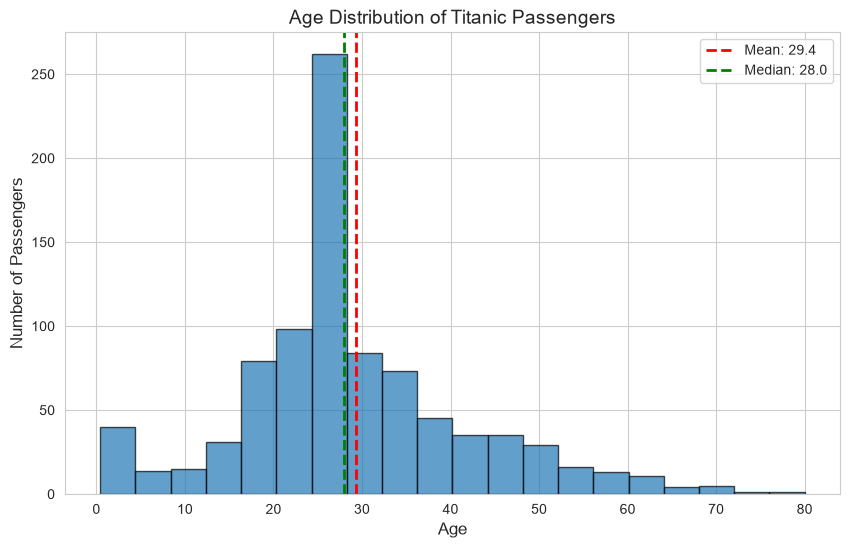

Most passengers were between 20-40 years old.


In [7]:
# Age Distribution
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Age'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Age Distribution of Titanic Passengers', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.axvline(df_clean['Age'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df_clean["Age"].mean():.1f}')
plt.axvline(df_clean['Age'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {df_clean["Age"].median():.1f}')
plt.legend()
plt.show()

print("Most passengers were between 20-40 years old.")

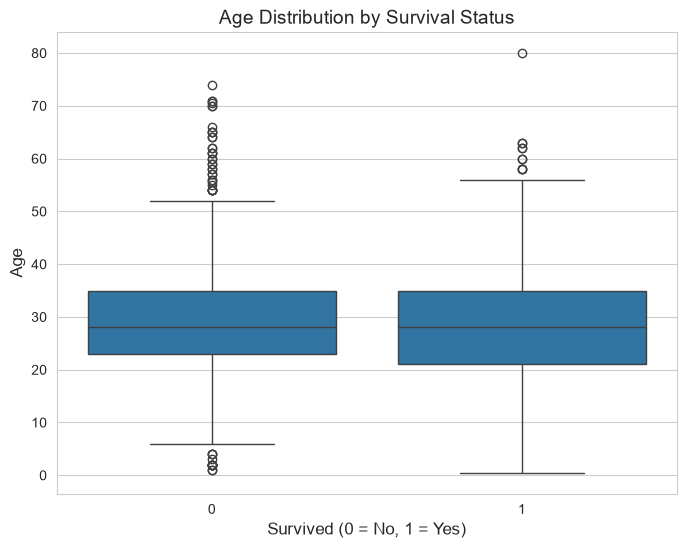

Surviving passengers tend to be younger on average.


In [8]:
# Age vs Survival
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Age', data=df_clean)
plt.title('Age Distribution by Survival Status', fontsize=14)
plt.xlabel('Survived (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.show()

print("Surviving passengers tend to be younger on average.")

C:\Users\pc\AppData\Local\Temp\ipykernel_18776\2621172628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_clean, palette=['blue', 'pink'])


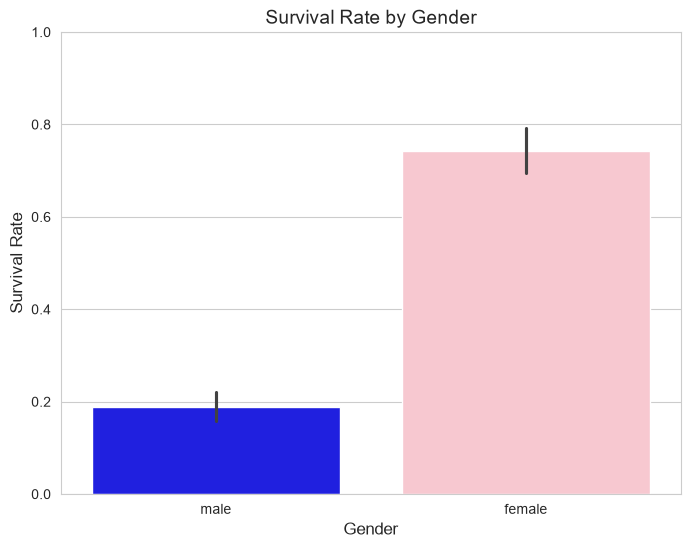

Female survival rate: 74.2%
Male survival rate: 18.9%
Women were 4x more likely to survive!


In [9]:
# Survival by Gender
plt.figure(figsize=(8, 6))
sns.barplot(x='Sex', y='Survived', data=df_clean, palette=['blue', 'pink'])
plt.title('Survival Rate by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.ylim(0, 1)
plt.show()

survival_sex = df_clean.groupby('Sex')['Survived'].mean()
print(f"Female survival rate: {survival_sex['female']*100:.1f}%")
print(f"Male survival rate: {survival_sex['male']*100:.1f}%")
print("Women were 4x more likely to survive!")

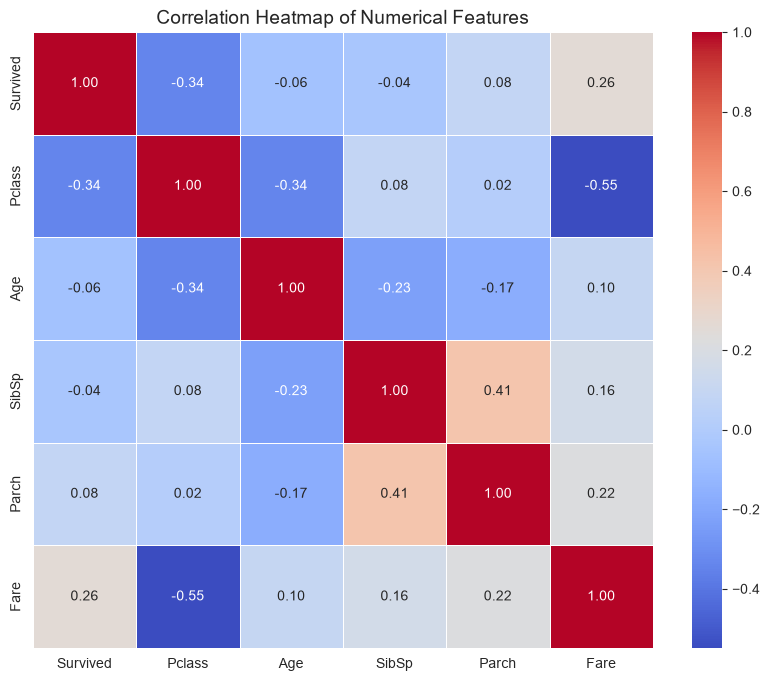

Key correlations:
Pclass vs Fare: -0.55 (higher class = higher fare)
Survived vs Pclass: -0.34 (lower class = lower survival)
Survived vs Fare: 0.26 (higher fare = higher survival)


In [10]:
# Correlation Heatmap
numerical_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df_clean[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

print("Key correlations:")
print(f"Pclass vs Fare: {corr_matrix.loc['Pclass', 'Fare']:.2f} (higher class = higher fare)")
print(f"Survived vs Pclass: {corr_matrix.loc['Survived', 'Pclass']:.2f} (lower class = lower survival)")
print(f"Survived vs Fare: {corr_matrix.loc['Survived', 'Fare']:.2f} (higher fare = higher survival)")

## Which Feature Most Affects Survival?

Based on my analysis, I think **Gender (Sex)** most affects survival.

**Why?**

1. From the bar chart, female survival rate is 74.2% while male survival rate is only 18.9%. This is a huge difference!

2. The "women and children first" rule was followed during the Titanic evacuation. Women were given priority on lifeboats.

3. Looking at the correlation heatmap, Sex is not included because it's categorical. But if we look at the survival rates by gender, the difference is the largest among all features.

**Other important features:**
- **Pclass (Ticket Class):** 1st class had higher survival (63%) vs 3rd class (24%)
- **Fare:** Higher fare passengers were more likely to survive
- **Age:** Younger passengers (especially children) had better survival rates

However, **Gender** is the strongest indicator because the evacuation protocol was gender-based.
